In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/cherngs/heart-disease-cleveland-uci/heart_cleveland_upload.csv


In [3]:
import pandas as pd

# 1) Load data
df = pd.read_csv("/kaggle/input/datasets/cherngs/heart-disease-cleveland-uci/heart_cleveland_upload.csv")

# 2) Basic inspection
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nFirst 5 rows:")
print(df.head())

print("\nTarget distribution:")
print(df["condition"].value_counts())
print(df["condition"].value_counts(normalize=True))

Shape: (297, 14)

Columns:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'condition']

Data types:
age            int64
sex            int64
cp             int64
trestbps       int64
chol           int64
fbs            int64
restecg        int64
thalach        int64
exang          int64
oldpeak      float64
slope          int64
ca             int64
thal           int64
condition      int64
dtype: object

First 5 rows:
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   69    1   0       160   234    1        2      131      0      0.1      1   
1   69    0   0       140   239    0        0      151      0      1.8      0   
2   66    0   0       150   226    0        0      114      0      2.6      2   
3   65    1   0       138   282    1        2      174      0      1.4      1   
4   64    1   0       110   211    0        2      144      1      1.8      1   

   ca  thal  condition  

In [4]:
# Missing values
print("Missing values:\n", df.isnull().sum())

# Duplicates
print("\nDuplicate rows:", df.duplicated().sum())

# Statistical summary
print("\nSummary stats:")
print(df.describe())

# Unique values (important for categorical)
for col in df.columns:
    print(f"\n{col} unique values:")
    print(df[col].unique())

Missing values:
 age          0
sex          0
cp           0
trestbps     0
chol         0
fbs          0
restecg      0
thalach      0
exang        0
oldpeak      0
slope        0
ca           0
thal         0
condition    0
dtype: int64

Duplicate rows: 0

Summary stats:
              age         sex          cp    trestbps        chol         fbs  \
count  297.000000  297.000000  297.000000  297.000000  297.000000  297.000000   
mean    54.542088    0.676768    2.158249  131.693603  247.350168    0.144781   
std      9.049736    0.468500    0.964859   17.762806   51.997583    0.352474   
min     29.000000    0.000000    0.000000   94.000000  126.000000    0.000000   
25%     48.000000    0.000000    2.000000  120.000000  211.000000    0.000000   
50%     56.000000    1.000000    2.000000  130.000000  243.000000    0.000000   
75%     61.000000    1.000000    3.000000  140.000000  276.000000    0.000000   
max     77.000000    1.000000    3.000000  200.000000  564.000000    1.000000

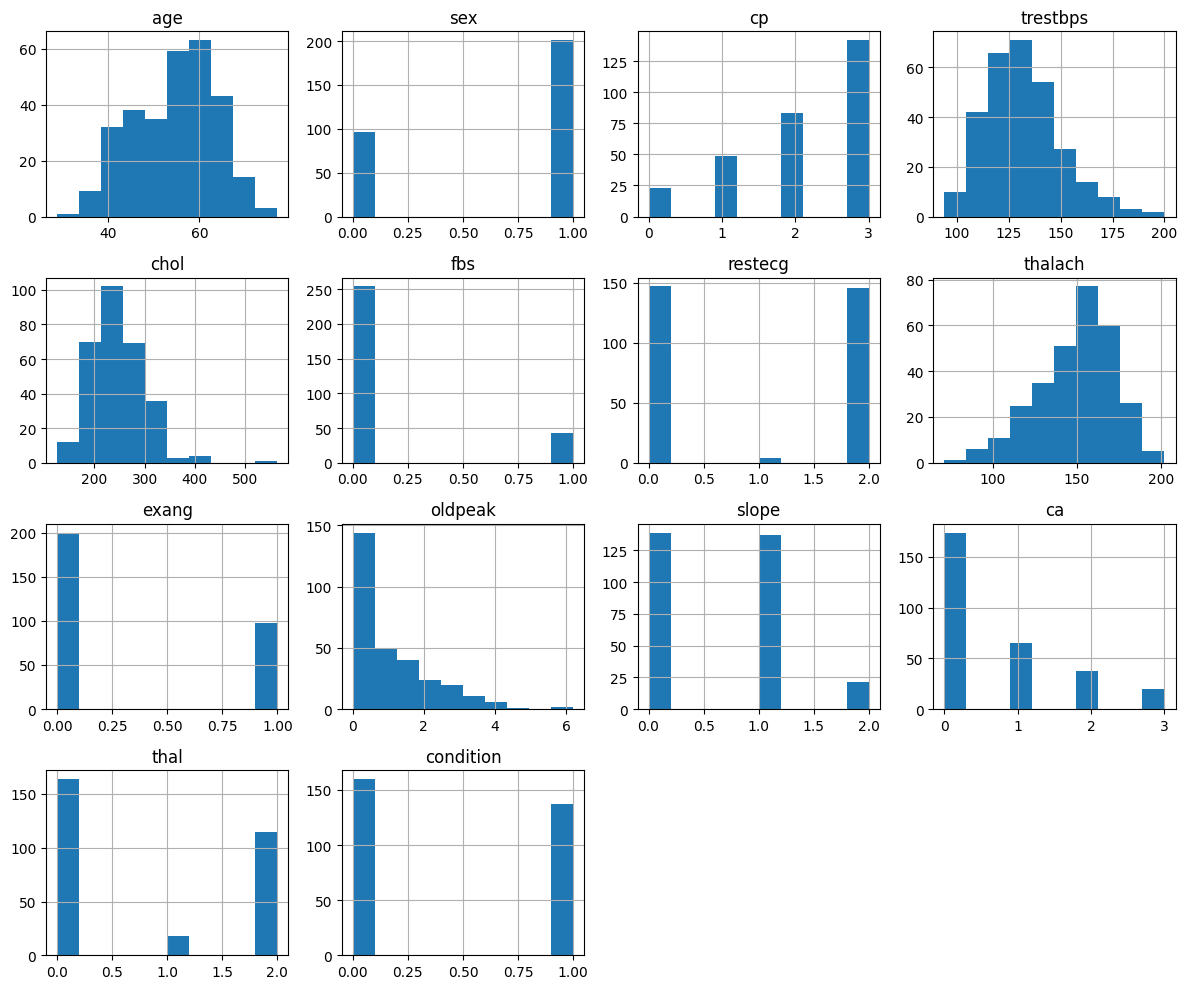

In [5]:
import matplotlib.pyplot as plt

df.hist(figsize=(12,10))
plt.tight_layout()
plt.show()

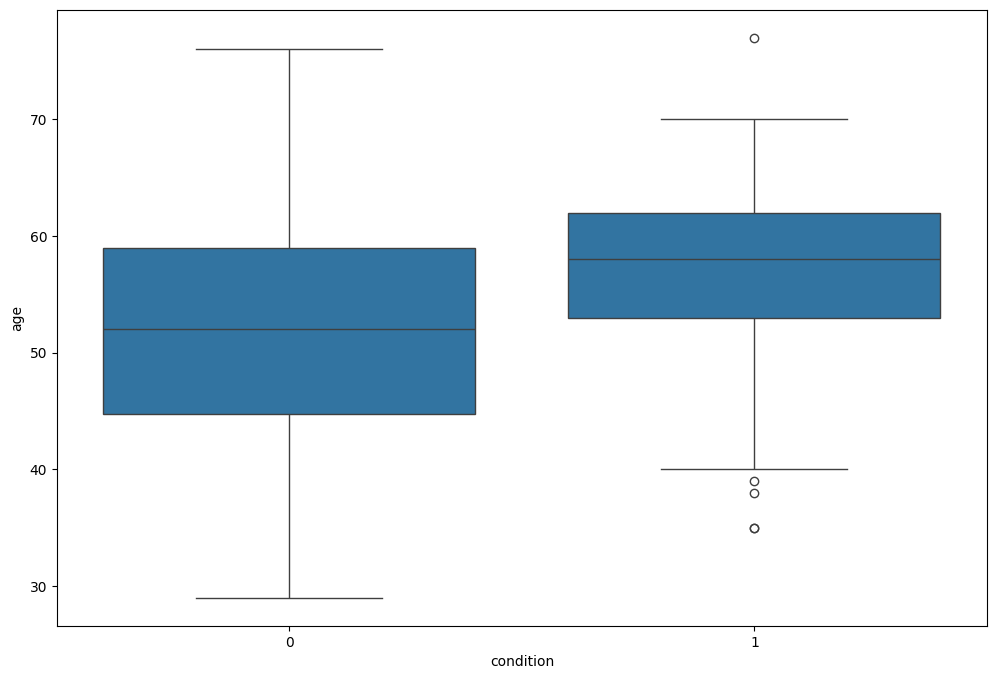

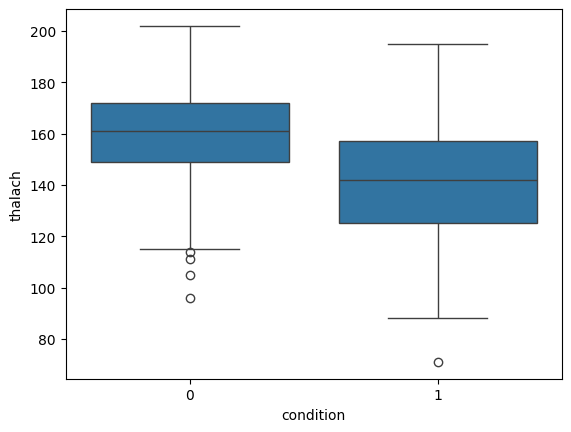

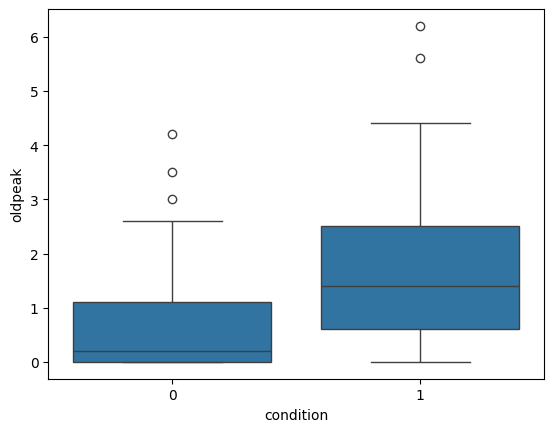

In [6]:
import seaborn as sns

plt.figure(figsize=(12,8))
sns.boxplot(x="condition", y="age", data=df)
plt.show()

sns.boxplot(x="condition", y="thalach", data=df)
plt.show()

sns.boxplot(x="condition", y="oldpeak", data=df)
plt.show()

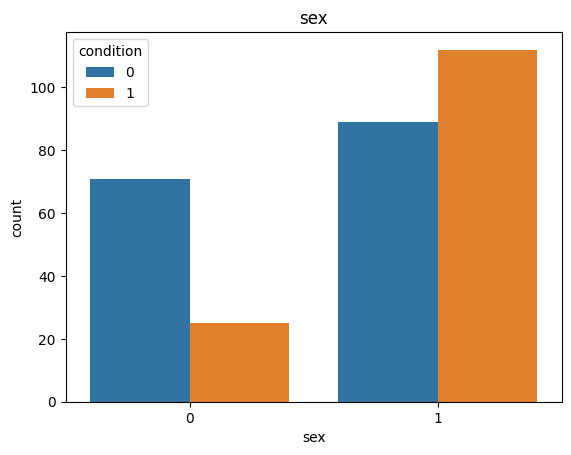

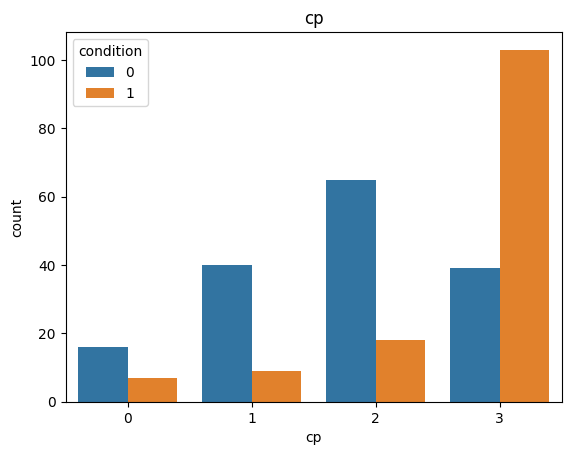

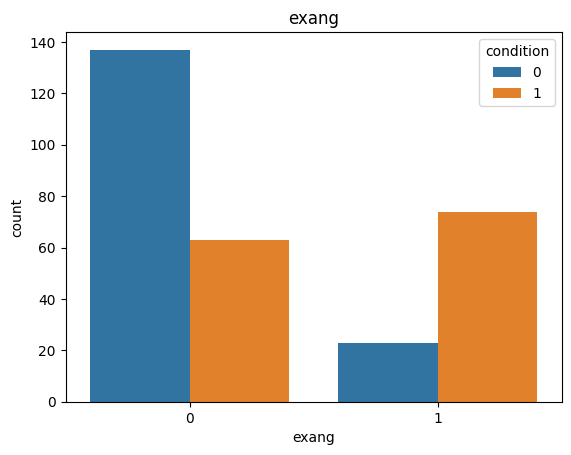

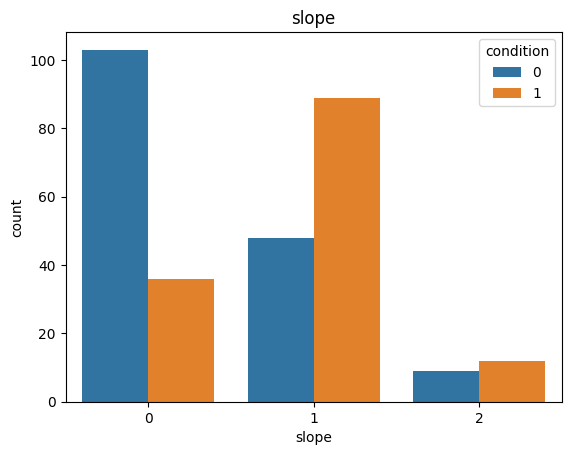

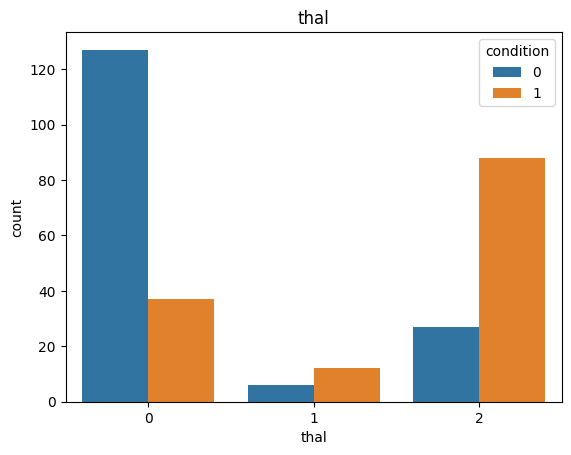

In [7]:
cols = ["sex", "cp", "exang", "slope", "thal"]

for col in cols:
    sns.countplot(x=col, hue="condition", data=df)
    plt.title(col)
    plt.show()

In [8]:
X = df.drop("condition", axis=1)
y = df["condition"]

In [9]:
num_cols = ["age", "trestbps", "chol", "thalach", "oldpeak"]

cat_cols = ["cp", "restecg", "slope", "ca", "thal"]

bin_cols = ["sex", "fbs", "exang"]

In [10]:
X = pd.get_dummies(X, columns=cat_cols, drop_first=True)

In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X[num_cols] = scaler.fit_transform(X[num_cols])

In [12]:
print(X.shape)
print(X.head())

(297, 20)
        age  sex  trestbps      chol  fbs   thalach  exang   oldpeak   cp_1  \
0  1.600302    1  1.596266 -0.257179    1 -0.812095      0 -0.820813  False   
1  1.600302    0  0.468418 -0.160859    0  0.061157      0  0.639470  False   
2  1.268242    0  1.032342 -0.411292    0 -1.554358      0  1.326662  False   
3  1.157555    1  0.355633  0.667499    1  1.065396      0  0.295874  False   
4  1.046868    1 -1.223355 -0.700254    0 -0.244481      1  0.639470  False   

    cp_2   cp_3  restecg_1  restecg_2  slope_1  slope_2   ca_1   ca_2   ca_3  \
0  False  False      False       True     True    False   True  False  False   
1  False  False      False      False    False    False  False   True  False   
2  False  False      False      False    False     True  False  False  False   
3  False  False      False       True     True    False   True  False  False   
4  False  False      False       True     True    False  False  False  False   

   thal_1  thal_2  
0   False   Fa

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [14]:
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

print("\nTrain target distribution:")
print(y_train.value_counts(normalize=True))

print("\nTest target distribution:")
print(y_test.value_counts(normalize=True))

Train shape: (237, 20)
Test shape: (60, 20)

Train target distribution:
condition
0    0.540084
1    0.459916
Name: proportion, dtype: float64

Test target distribution:
condition
0    0.533333
1    0.466667
Name: proportion, dtype: float64


In [15]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(X_train, y_train)

LogisticRegression()

In [16]:
y_pred = model.predict(X_test)

In [17]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.9166666666666666

Classification Report:
              precision    recall  f1-score   support

           0       0.86      1.00      0.93        32
           1       1.00      0.82      0.90        28

    accuracy                           0.92        60
   macro avg       0.93      0.91      0.91        60
weighted avg       0.93      0.92      0.92        60


Confusion Matrix:
[[32  0]
 [ 5 23]]


In [18]:
model = LogisticRegression(max_iter=1000)

In [20]:
model.fit(X_train, y_train)
y_prob = model.predict_proba(X_test)[:, 1]

In [22]:
import numpy as np

threshold = 0.3  # thử thấp hơn

y_pred_new = (y_prob >= threshold).astype(int)

In [23]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, y_pred_new))
print(confusion_matrix(y_test, y_pred_new))

              precision    recall  f1-score   support

           0       0.96      0.78      0.86        32
           1       0.79      0.96      0.87        28

    accuracy                           0.87        60
   macro avg       0.88      0.87      0.87        60
weighted avg       0.88      0.87      0.87        60

[[25  7]
 [ 1 27]]


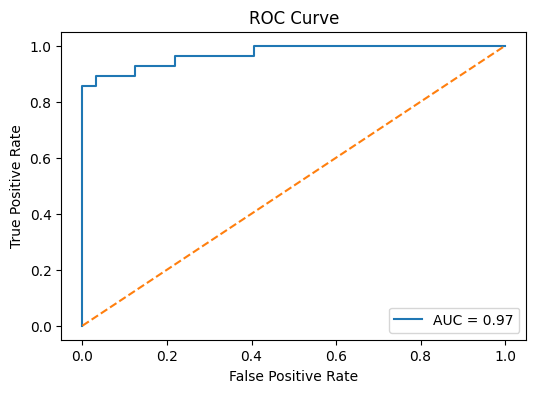

In [24]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

y_prob = model.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {auc:.2f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [26]:
import numpy as np

threshold = 0.2  # thử thấp hơn

y_pred_new = (y_prob >= threshold).astype(int)

In [27]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, y_pred_new))
print(confusion_matrix(y_test, y_pred_new))

              precision    recall  f1-score   support

           0       0.96      0.69      0.80        32
           1       0.73      0.96      0.83        28

    accuracy                           0.82        60
   macro avg       0.84      0.83      0.82        60
weighted avg       0.85      0.82      0.81        60

[[22 10]
 [ 1 27]]



--------------------------------------------------
THRESHOLD = 0.5
--------------------------------------------------
Accuracy: 0.9166666666666666
Precision (class 1): 1.0
Recall    (class 1): 0.8214
F1-score  (class 1): 0.902
TN, FP, FN, TP: 32 0 5 23

Classification Report:
              precision    recall  f1-score   support

           0       0.86      1.00      0.93        32
           1       1.00      0.82      0.90        28

    accuracy                           0.92        60
   macro avg       0.93      0.91      0.91        60
weighted avg       0.93      0.92      0.92        60

Confusion Matrix:
[[32  0]
 [ 5 23]]

--------------------------------------------------
THRESHOLD = 0.4
--------------------------------------------------
Accuracy: 0.9166666666666666
Precision (class 1): 0.96
Recall    (class 1): 0.8571
F1-score  (class 1): 0.9057
TN, FP, FN, TP: 31 1 4 24

Classification Report:
              precision    recall  f1-score   support

           0       0.89

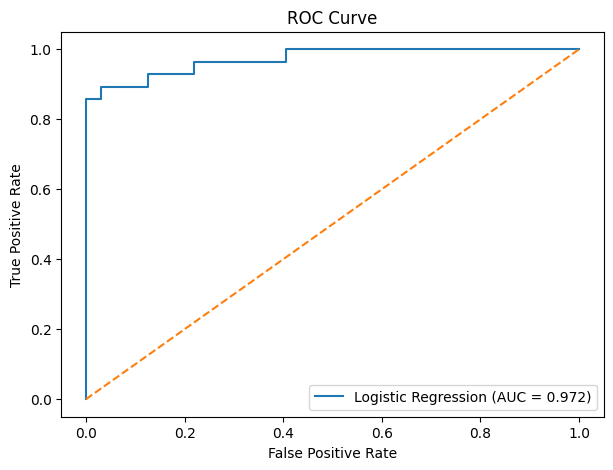


TOP 15 MOST IMPORTANT FEATURES (by abs coefficient)
      feature  coefficient  abs_coefficient
16       ca_2     1.724316         1.724316
10       cp_3     1.329495         1.329495
15       ca_1     1.178990         1.178990
17       ca_3     1.112458         1.112458
19     thal_2     1.020085         1.020085
1         sex     0.871126         0.871126
6       exang     0.636773         0.636773
13    slope_1     0.605490         0.605490
7     oldpeak     0.570667         0.570667
8        cp_1     0.548886         0.548886
5     thalach    -0.496690         0.496690
12  restecg_2     0.243440         0.243440
2    trestbps     0.222369         0.222369
4         fbs    -0.201569         0.201569
3        chol     0.160238         0.160238


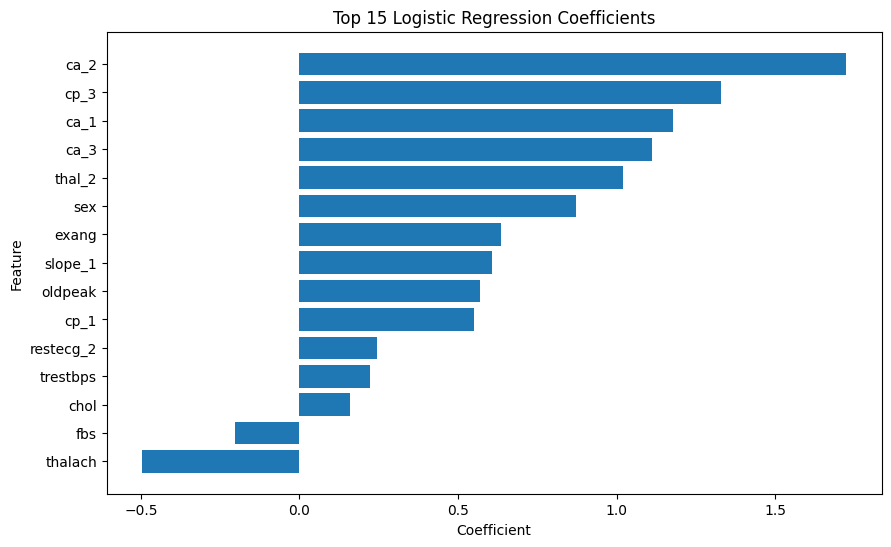

In [28]:
# 9. THRESHOLD TESTING
# =========================================================

def evaluate_threshold(y_true, y_prob, threshold=0.5):
    y_pred_t = (y_prob >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred_t)
    report = classification_report(y_true, y_pred_t, output_dict=True)

    tn, fp, fn, tp = cm.ravel()

    print("\n" + "-" * 50)
    print(f"THRESHOLD = {threshold}")
    print("-" * 50)
    print("Accuracy:", accuracy_score(y_true, y_pred_t))
    print("Precision (class 1):", round(report["1"]["precision"], 4))
    print("Recall    (class 1):", round(report["1"]["recall"], 4))
    print("F1-score  (class 1):", round(report["1"]["f1-score"], 4))
    print("TN, FP, FN, TP:", tn, fp, fn, tp)
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred_t))
    print("Confusion Matrix:")
    print(cm)

thresholds = [0.5, 0.4, 0.3, 0.2]
for t in thresholds:
    evaluate_threshold(y_test, y_prob, threshold=t)


# =========================================================
# 10. ROC CURVE
# =========================================================

fpr, tpr, roc_thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {roc_auc_score(y_test, y_prob):.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


# =========================================================
# 11. COEFFICIENT IMPORTANCE
# =========================================================

coef_df = pd.DataFrame({
    "feature": X_train.columns,
    "coefficient": model.coef_[0]
})

coef_df["abs_coefficient"] = coef_df["coefficient"].abs()
coef_df = coef_df.sort_values("abs_coefficient", ascending=False)

print("\n" + "=" * 60)
print("TOP 15 MOST IMPORTANT FEATURES (by abs coefficient)")
print(coef_df.head(15))

plt.figure(figsize=(10, 6))
top_n = 15
plot_df = coef_df.head(top_n).sort_values("coefficient")
plt.barh(plot_df["feature"], plot_df["coefficient"])
plt.title(f"Top {top_n} Logistic Regression Coefficients")
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.show()

Accuracy: 0.8166666666666667

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.91      0.84        32
           1       0.87      0.71      0.78        28

    accuracy                           0.82        60
   macro avg       0.83      0.81      0.81        60
weighted avg       0.82      0.82      0.81        60


Confusion Matrix:
[[29  3]
 [ 8 20]]

=== THRESHOLD 0.5 ===
              precision    recall  f1-score   support

           0       0.78      0.91      0.84        32
           1       0.87      0.71      0.78        28

    accuracy                           0.82        60
   macro avg       0.83      0.81      0.81        60
weighted avg       0.82      0.82      0.81        60

[[29  3]
 [ 8 20]]

=== THRESHOLD 0.4 ===
              precision    recall  f1-score   support

           0       0.80      0.88      0.84        32
           1       0.84      0.75      0.79        28

    accuracy              

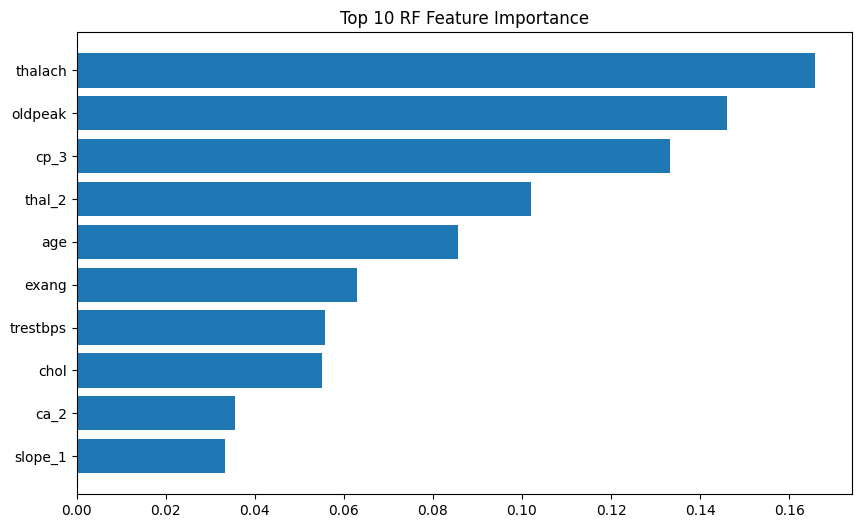

In [29]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=5,
    random_state=42
)

rf.fit(X_train, y_train)

y_prob_rf = rf.predict_proba(X_test)[:, 1]
y_pred_rf = rf.predict(X_test)

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

def eval_rf(threshold):
    y_pred_t = (y_prob_rf >= threshold).astype(int)
    print(f"\n=== THRESHOLD {threshold} ===")
    print(classification_report(y_test, y_pred_t))
    print(confusion_matrix(y_test, y_pred_t))

for t in [0.5, 0.4, 0.3, 0.2]:
    eval_rf(t)

import pandas as pd
import matplotlib.pyplot as plt

feat_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": rf.feature_importances_
}).sort_values("importance", ascending=False)

print(feat_importance.head(10))

plt.figure(figsize=(10,6))
plt.barh(feat_importance.head(10)["feature"],
         feat_importance.head(10)["importance"])
plt.gca().invert_yaxis()
plt.title("Top 10 RF Feature Importance")
plt.show()

SHAP summary plot for class 1 (disease)


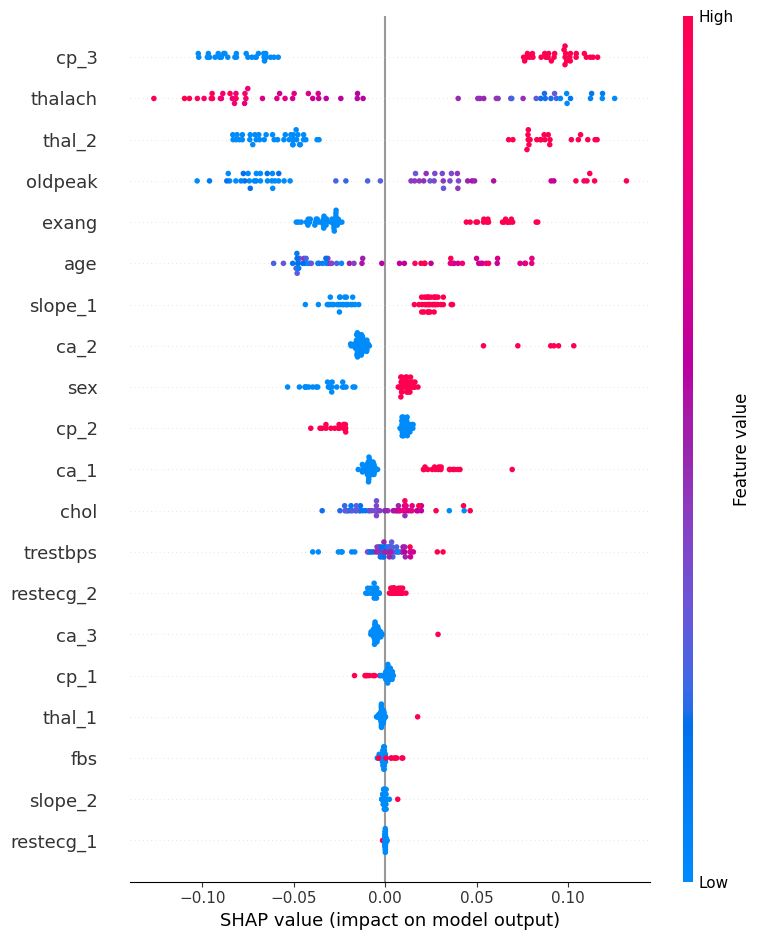

SHAP bar plot


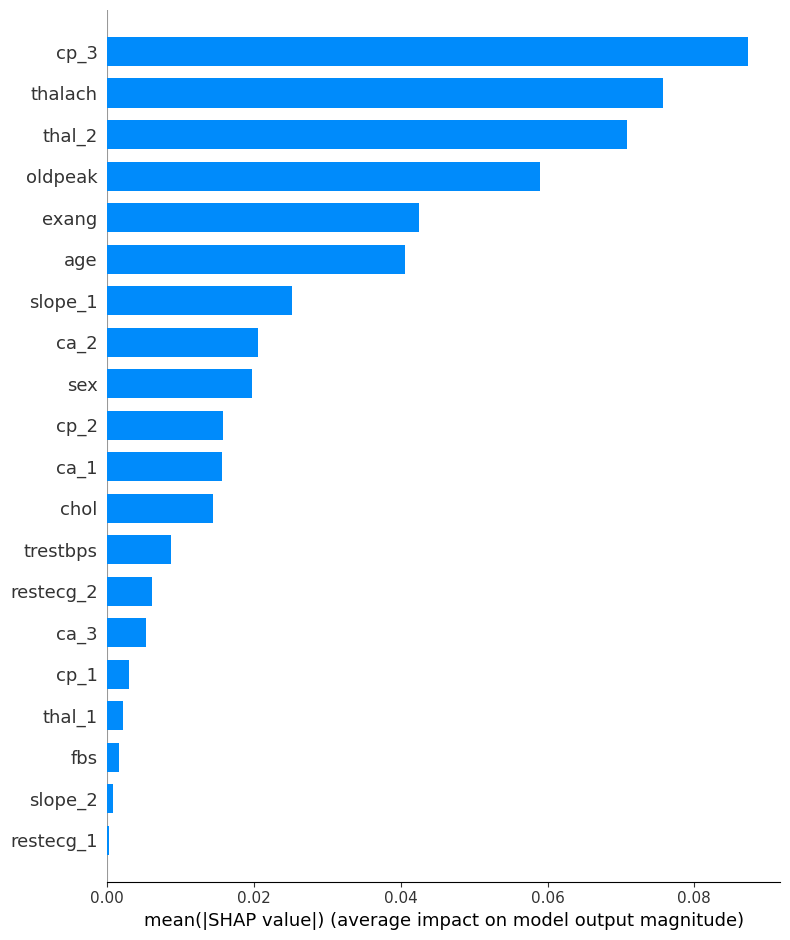


Explaining test row index: 0
Predicted probability of disease: 0.2597117409509967
Actual label: 0


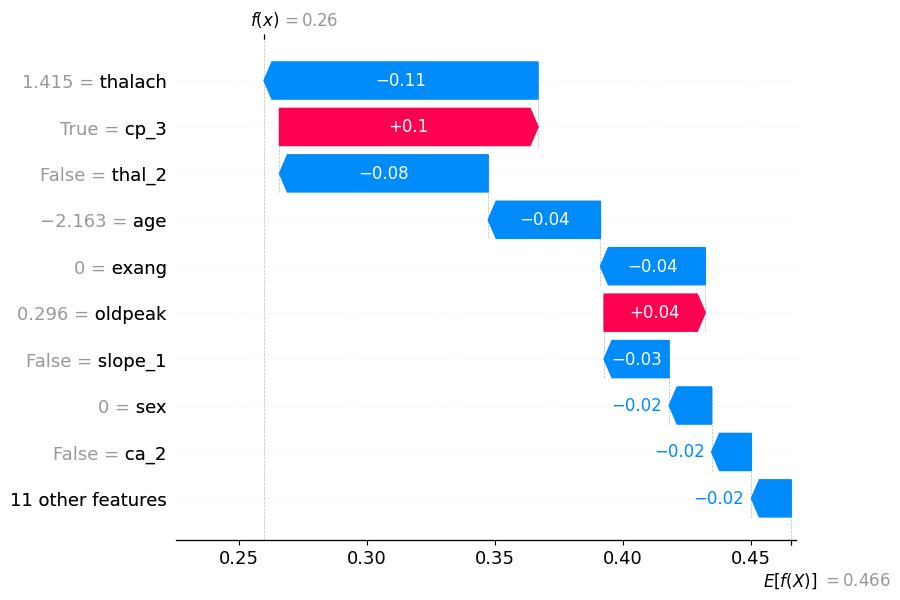

   predicted_probability risk_band_quantile
0               0.259712           Low risk
1               0.539014        Medium risk
2               0.172693           Low risk
3               0.387892        Medium risk
4               0.101414           Low risk
risk_band_quantile
Low risk       20
Medium risk    20
High risk      20
Name: count, dtype: int64


In [34]:
# =========================
# STEP 9: SHAP EXPLAINABILITY
# =========================

# If needed:
# !pip install shap -q

import shap
import matplotlib.pyplot as plt

# 1) Create explainer for Random Forest
explainer = shap.TreeExplainer(rf)

# 2) Compute SHAP values
shap_values = explainer.shap_values(X_test)

# For binary classification:
# shap_values[1] = contribution toward class 1 (disease)
if isinstance(shap_values, list):
    shap_class1 = shap_values[1]
    expected_value = explainer.expected_value[1]
else:
    # fallback for newer shap versions
    shap_class1 = shap_values[:, :, 1] if len(shap_values.shape) == 3 else shap_values
    expected_value = explainer.expected_value

# 3) Global importance summary
print("SHAP summary plot for class 1 (disease)")
shap.summary_plot(shap_class1, X_test)

# 4) Bar plot = cleaner global ranking
print("SHAP bar plot")
shap.summary_plot(shap_class1, X_test, plot_type="bar")

# 5) Explain one patient prediction
sample_idx = 0

print(f"\nExplaining test row index: {sample_idx}")
print("Predicted probability of disease:", rf.predict_proba(X_test.iloc[[sample_idx]])[0, 1])
print("Actual label:", y_test.iloc[sample_idx])

shap.plots.force(
    expected_value[1],
    shap_class1[sample_idx],
    X_test.iloc[sample_idx]
)
plt.show()

# 6) Waterfall plot (cleaner than force plot in many cases)
shap_explanation = shap.Explanation(
    values=shap_class1[sample_idx],      # chỉ 1 row
    base_values=expected_value[1],       # chỉ 1 value
    data=X_test.iloc[sample_idx],
    feature_names=X_test.columns
)

shap.plots.waterfall(shap_explanation, max_display=10)


# Quantile-based risk bands
results = pd.DataFrame({
    "predicted_probability": rf.predict_proba(X_test)[:, 1],
    "actual_label": y_test.values
})

results["risk_band_quantile"] = pd.qcut(
    results["predicted_probability"],
    q=3,
    labels=["Low risk", "Medium risk", "High risk"]
)

print(results[["predicted_probability", "risk_band_quantile"]].head())
print(results["risk_band_quantile"].value_counts())

In [35]:
# STEP 11: SAVE MODEL + METADATA

import joblib

artifact = {
    "model": rf,                          # trained Random Forest model
    "feature_columns": X.columns.tolist(),# final columns after get_dummies
    "categorical_columns": cat_cols       # original categorical columns before encoding
}

joblib.dump(artifact, "heart_rf_pipeline.pkl")

print("✅ Model artifact saved as heart_rf_pipeline.pkl")


# STEP 12 + 13 + 14: PREDICT USER + CONVERT TO RISK + WRAP FUNCTION

import pandas as pd
import joblib

# load saved artifact
artifact = joblib.load("heart_rf_pipeline.pkl")

model = artifact["model"]
feature_columns = artifact["feature_columns"]
categorical_columns = artifact["categorical_columns"]


def probability_to_risk(prob):
    """
    Convert probability to risk band.
    Adjust thresholds if you want stricter / looser risk rules.
    """
    if prob < 0.33:
        return "Low risk"
    elif prob < 0.66:
        return "Medium risk"
    else:
        return "High risk"


def prepare_user_input(user_dict, categorical_columns, feature_columns):
    """
    Convert raw user input -> dataframe -> one-hot encode -> align columns
    """
    df = pd.DataFrame([user_dict])

    # one-hot encode same way as training
    df = pd.get_dummies(df, columns=categorical_columns, drop_first=True)

    # align with training columns
    df = df.reindex(columns=feature_columns, fill_value=0)

    return df


def predict_heart_risk(user_dict):
    """
    Main prediction wrapper
    Input: raw user dictionary
    Output: probability, class, risk band
    """
    user_df = prepare_user_input(
        user_dict=user_dict,
        categorical_columns=categorical_columns,
        feature_columns=feature_columns
    )

    prob = model.predict_proba(user_df)[0, 1]
    pred_class = int(prob >= 0.5)
    risk_band = probability_to_risk(prob)

    return {
        "predicted_probability": round(float(prob), 4),
        "predicted_class": pred_class,
        "risk_band": risk_band
    }




# TEST SAMPLE USER

sample_user = {
    "age": 57,
    "sex": 1,
    "cp": 2,
    "trestbps": 140,
    "chol": 241,
    "fbs": 0,
    "restecg": 1,
    "thalach": 123,
    "exang": 1,
    "oldpeak": 0.2,
    "slope": 1,
    "ca": 0,
    "thal": 2
}

result = predict_heart_risk(sample_user)
print(result)





✅ Model artifact saved as heart_rf_pipeline.pkl
{'predicted_probability': 0.3789, 'predicted_class': 0, 'risk_band': 'Medium risk'}


In [36]:
from fastapi import FastAPI
from pydantic import BaseModel
import pandas as pd
import joblib

# load artifact once when API starts
artifact = joblib.load("heart_rf_pipeline.pkl")

model = artifact["model"]
feature_columns = artifact["feature_columns"]
categorical_columns = artifact["categorical_columns"]

app = FastAPI(title="Heart Disease Risk API")


class HeartInput(BaseModel):
    age: float
    sex: int
    cp: int
    trestbps: float
    chol: float
    fbs: int
    restecg: int
    thalach: float
    exang: int
    oldpeak: float
    slope: int
    ca: int
    thal: int


def probability_to_risk(prob):
    if prob < 0.33:
        return "Low risk"
    elif prob < 0.66:
        return "Medium risk"
    else:
        return "High risk"


def prepare_user_input(user_dict):
    df = pd.DataFrame([user_dict])
    df = pd.get_dummies(df, columns=categorical_columns, drop_first=True)
    df = df.reindex(columns=feature_columns, fill_value=0)
    return df


@app.get("/")
def home():
    return {"message": "Heart Disease Risk API is running"}


@app.post("/predict")
def predict(input_data: HeartInput):
    user_dict = input_data.model_dump()

    user_df = prepare_user_input(user_dict)

    prob = model.predict_proba(user_df)[0, 1]
    pred_class = int(prob >= 0.5)
    risk_band = probability_to_risk(prob)

    return {
        "predicted_probability": round(float(prob), 4),
        "predicted_class": pred_class,
        "risk_band": risk_band
    }




In [37]:
import joblib

model = joblib.load("heart_rf_pipeline.pkl")

print(type(model))          # xem loại model
print(model)                # overview

<class 'dict'>
{'model': RandomForestClassifier(max_depth=5, n_estimators=200, random_state=42), 'feature_columns': ['age', 'sex', 'trestbps', 'chol', 'fbs', 'thalach', 'exang', 'oldpeak', 'cp_1', 'cp_2', 'cp_3', 'restecg_1', 'restecg_2', 'slope_1', 'slope_2', 'ca_1', 'ca_2', 'ca_3', 'thal_1', 'thal_2'], 'categorical_columns': ['cp', 'restecg', 'slope', 'ca', 'thal']}
